# 🌿 Level 1 — Task 3: K-Nearest Neighbors (KNN) Classifier
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Iris Dataset (1) iris.csv)

**Objectives:**
- Train a KNN model on a labeled dataset
- Evaluate performance using accuracy, confusion matrix, and precision/recall
- Use different values of K and compare the results

**Tools:** Python, Scikit-learn, Pandas

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Mounted at /content/drive
✅ Google Drive mounted successfully


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score,
    f1_score, classification_report
)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## Step 3: Load the Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Data Set For Task/1) iris.csv')
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 4: Explore the Dataset

In [4]:
print('=== Dataset Info ===')
df.info()
print('\n=== Class Distribution ===')
print(df['species'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## Step 5: Preprocess the Dataset

In [6]:
# Encode target column
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])
print('=== Label Encoding ===')
print(df[['species', 'species_encoded']].drop_duplicates())

# Define features and target
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features]
y = df['species_encoded']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

=== Label Encoding ===
        species  species_encoded
0        setosa                0
50   versicolor                1
100   virginica                2

Training samples : 120
Testing samples  : 30


## Step 6: Train KNN with Different Values of K

In [7]:
# Test K values from 1 to 20
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f'K = {k:2d}  →  Accuracy: {acc*100:.2f}%')

K =  1  →  Accuracy: 96.67%
K =  2  →  Accuracy: 93.33%
K =  3  →  Accuracy: 93.33%
K =  4  →  Accuracy: 93.33%
K =  5  →  Accuracy: 93.33%
K =  6  →  Accuracy: 93.33%
K =  7  →  Accuracy: 96.67%
K =  8  →  Accuracy: 93.33%
K =  9  →  Accuracy: 96.67%
K = 10  →  Accuracy: 96.67%
K = 11  →  Accuracy: 96.67%
K = 12  →  Accuracy: 96.67%
K = 13  →  Accuracy: 96.67%
K = 14  →  Accuracy: 93.33%
K = 15  →  Accuracy: 93.33%
K = 16  →  Accuracy: 93.33%
K = 17  →  Accuracy: 96.67%
K = 18  →  Accuracy: 96.67%
K = 19  →  Accuracy: 96.67%
K = 20  →  Accuracy: 93.33%


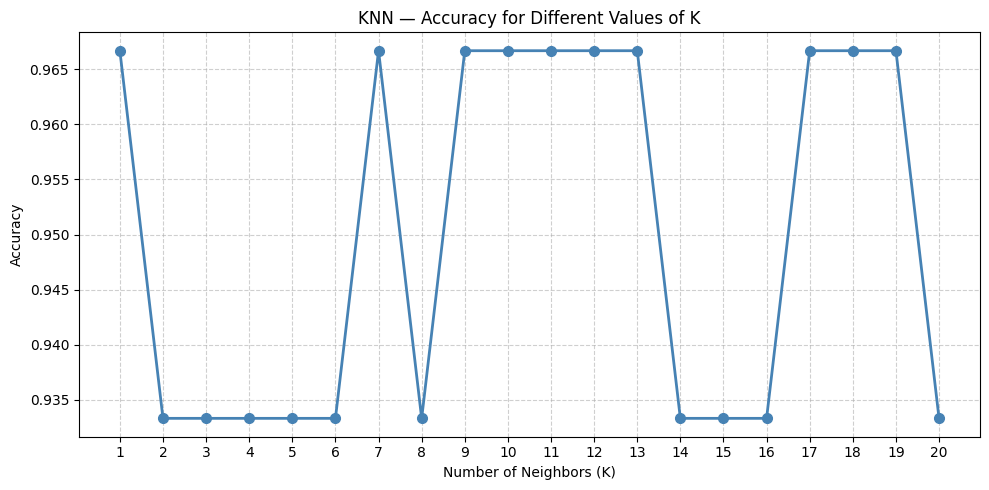


✅ Best K = 1 with Accuracy = 96.67%


In [8]:
# Plot K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2, markersize=7)
plt.title('KNN — Accuracy for Different Values of K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print(f'\n✅ Best K = {best_k} with Accuracy = {max(accuracies)*100:.2f}%')

## Step 7: Train Final KNN Model with Best K

In [9]:
# Train with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print(f'✅ Final KNN model trained with K = {best_k}')

✅ Final KNN model trained with K = 1


## Step 8: Evaluate the Model

In [10]:
accuracy  = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall    = recall_score(y_test, y_pred_best, average='weighted')
f1        = f1_score(y_test, y_pred_best, average='weighted')

print('=======================================')
print(f'   MODEL EVALUATION  (K = {best_k})')
print('=======================================')
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=======================================')

   MODEL EVALUATION  (K = 1)
  Accuracy  : 96.67%
  Precision : 96.97%
  Recall    : 96.67%
  F1-Score  : 96.66%


In [11]:
# Full classification report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Step 9: Confusion Matrix

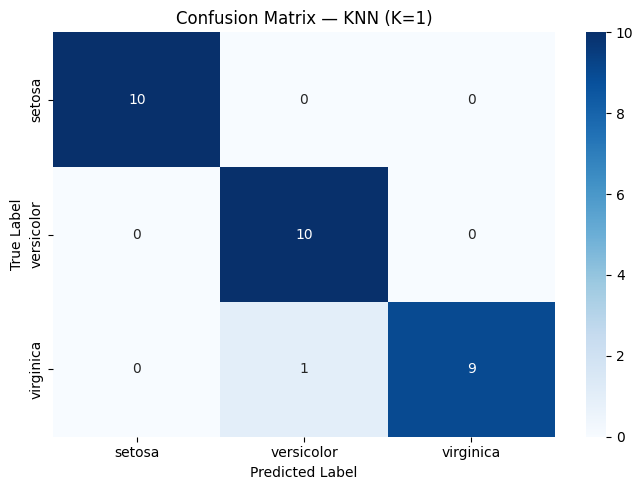


📌 Interpretation:
  Diagonal values = correct predictions
  Off-diagonal values = misclassifications


In [12]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix — KNN (K={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('\n📌 Interpretation:')
print('  Diagonal values = correct predictions')
print('  Off-diagonal values = misclassifications')

## Step 10: Compare K=1, K=5, K=10, K=15, K=20

In [13]:
compare_k = [1, 5, 10, 15, 20]

print(f'{'K':<5} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1-Score':>10}')
print('-' * 52)

for k in compare_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_temp = knn_temp.predict(X_test)

    acc  = accuracy_score(y_test, y_temp)
    prec = precision_score(y_test, y_temp, average='weighted')
    rec  = recall_score(y_test, y_temp, average='weighted')
    f1_  = f1_score(y_test, y_temp, average='weighted')

    print(f'{k:<5} {acc*100:>9.2f}%  {prec*100:>10.2f}%  {rec*100:>8.2f}%  {f1_*100:>8.2f}%')

K       Accuracy    Precision     Recall   F1-Score
----------------------------------------------------
1         96.67%       96.97%     96.67%     96.66%
5         93.33%       94.44%     93.33%     93.27%
10        96.67%       96.97%     96.67%     96.66%
15        93.33%       93.33%     93.33%     93.33%
20        93.33%       93.33%     93.33%     93.33%


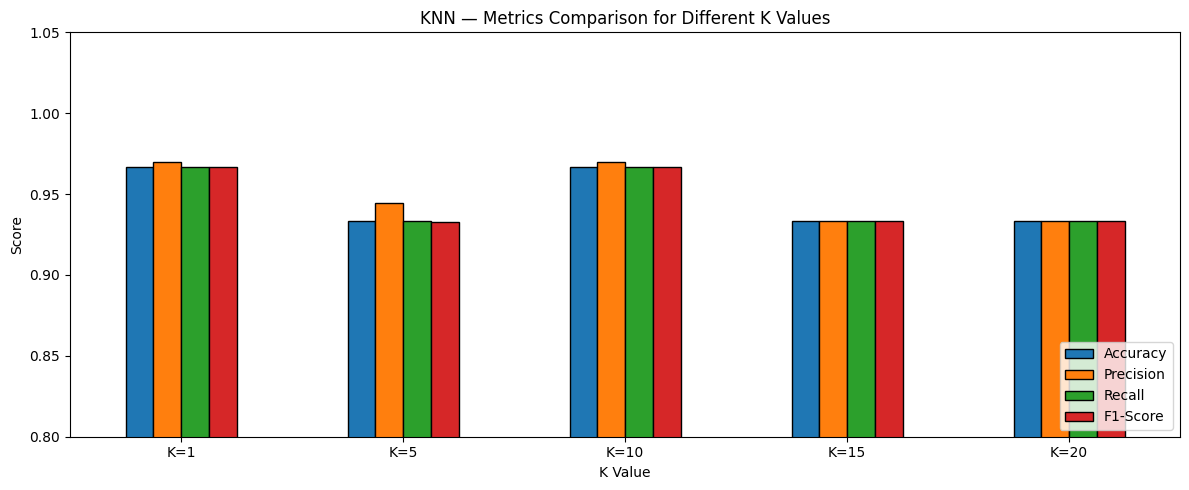

In [14]:
# Visualize comparison
metrics_data = []
for k in compare_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_temp = knn_temp.predict(X_test)
    metrics_data.append({
        'K': f'K={k}',
        'Accuracy':  accuracy_score(y_test, y_temp),
        'Precision': precision_score(y_test, y_temp, average='weighted'),
        'Recall':    recall_score(y_test, y_temp, average='weighted'),
        'F1-Score':  f1_score(y_test, y_temp, average='weighted')
    })

metrics_df = pd.DataFrame(metrics_data).set_index('K')

metrics_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('KNN — Metrics Comparison for Different K Values')
plt.ylabel('Score')
plt.xlabel('K Value')
plt.xticks(rotation=0)
plt.ylim(0.8, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()